# 01 — Source: Market метрики (Kaggle Puzzle category)

## 0. Контекст

**Источник данных:** Kaggle dataset `gauthamp10/google-playstore-apps` — снапшот 2,3 млн приложений Google Play (2021).

**8 колонок Market-группы** описывают конкурентное окружение продукта в категории Puzzle:

| Колонка | Описание |
|---|---|
| competitor_count | Число приложений в категории Puzzle на дату |
| category_rank | Позиция продукта в категории по установкам |
| competitor_count_change | Изменение числа конкурентов день-к-дню |
| competition_volatility_7d | Std competitor_count за 7 дней (рыночная нестабильность) |
| category_rank_ma14, category_rank_ma30 | Скользящее среднее ранга (14 и 30 дней) |
| rank_volatility_7d | Std category_rank за 7 дней (стабильность позиции) |
| rank_improvement | Изменение позиции (улучшение/ухудшение) |

⚠️ **Особенность:** все 8 market-колонок **идентичны** для com.labpixies.flood и com.google.flood2 — продукты делят категорию Puzzle и наблюдаются в один период. Это будет программно проверено в §1.

**Следствие для модели:** market-признаки описывают только рыночный фон. Они не различают продукты и не могут служить разделяющим сигналом «успех vs провал».

**Гипотеза:** market-метрики — proxy для общего состояния рынка, могут улавливать «макро»-факторы (например, рост конкуренции → давление на retention).


In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset
from notebooks._common import (
    APP_PALETTE, APP_LABEL_MAP, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    split_by_app, top_correlated_pairs, comparison_table,
    add_app_legend, annotate_sample_size, check_inf_columns,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "01_source_market"
df = load_dataset()
print(f"Dataset: {df.shape}")


Dataset: (222, 60)


In [2]:
MARKET_COLS = [
    "competitor_count", "category_rank",
    "competitor_count_change", "competition_volatility_7d",
    "category_rank_ma14", "category_rank_ma30",
    "rank_volatility_7d", "rank_improvement",
]
assert len(MARKET_COLS) == 8
print(f"MARKET_COLS: {len(MARKET_COLS)} колонок")


MARKET_COLS: 8 колонок


## 1. Загрузка и подтверждение идентичности f1/f2

In [3]:
df_f1, df_f2 = split_by_app(df)
print(f"Flood-It!   shape: {df_f1.shape}")
print(f"Flood-It! 2 shape: {df_f2.shape}")
print()

from notebooks._common import assert_shared_columns

assert_shared_columns(df_f1, df_f2, MARKET_COLS)
print(f"✓ Все {len(MARKET_COLS)} market-колонок идентичны для f1 и f2 (программная проверка)")
# Diagnostic: имя каждой проверенной колонки
for col in MARKET_COLS:
    print(f"  {col}: f1 == f2 → True")

# Работаем с общей выборкой (значения одинаковы для обоих приложений)
df_market_shared = df_f1[["date"] + MARKET_COLS].copy().reset_index(drop=True)
print(f"df_market_shared shape: {df_market_shared.shape}")

Flood-It!   shape: (111, 60)
Flood-It! 2 shape: (111, 60)

✓ Все 8 market-колонок идентичны для f1 и f2 (программная проверка)
  competitor_count: f1 == f2 → True
  category_rank: f1 == f2 → True
  competitor_count_change: f1 == f2 → True
  competition_volatility_7d: f1 == f2 → True
  category_rank_ma14: f1 == f2 → True
  category_rank_ma30: f1 == f2 → True
  rank_volatility_7d: f1 == f2 → True
  rank_improvement: f1 == f2 → True
df_market_shared shape: (111, 9)


## 2. Качество данных

In [4]:
# NaN counts
missing_summary = df_market_shared[MARKET_COLS].isna().sum().rename("NaN_count")
missing_summary = missing_summary.to_frame()
missing_summary["pct"] = (missing_summary["NaN_count"] / len(df_market_shared) * 100).round(1)
display(missing_summary.sort_values("NaN_count", ascending=False))


,NaN_count,pct
competition_volatility_7d,1,0.9
competitor_count_change,1,0.9
rank_volatility_7d,1,0.9
rank_improvement,1,0.9
competitor_count,0,0.0
category_rank,0,0.0
category_rank_ma30,0,0.0
category_rank_ma14,0,0.0


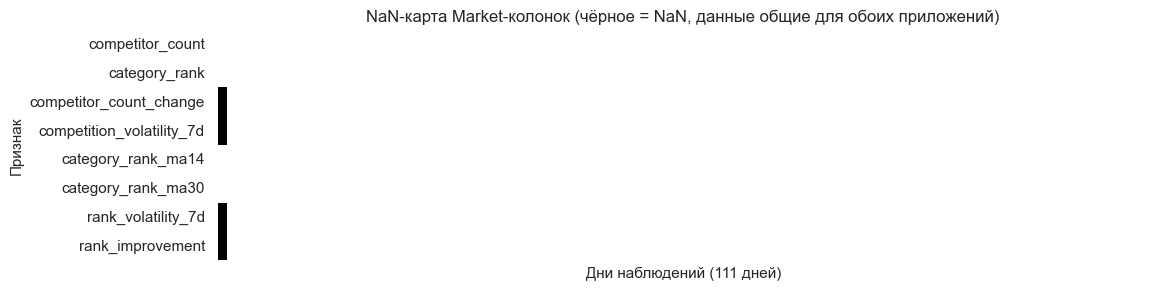

Сохранено: nan_heatmap.pdf


In [5]:
# NaN heatmap (строим всегда для полноты — 1 NaN в start row для разностных колонок)
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(
    df_market_shared[MARKET_COLS].isna().T.astype(int),
    cmap="binary", cbar=False, xticklabels=False, ax=ax,
)
ax.set_title("NaN-карта Market-колонок (чёрное = NaN, данные общие для обоих приложений)")
ax.set_ylabel("Признак")
ax.set_xlabel("Дни наблюдений (111 дней)")
save_figure("nan_heatmap", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: nan_heatmap.pdf")


In [6]:
# Проверка inf-значений
inf_cols = check_inf_columns(df_market_shared, MARKET_COLS)
if not inf_cols:
    print("inf-значений нет — OK")

# Sanity: competitor_count > 0, category_rank > 0
assert (df_market_shared["competitor_count"].dropna() > 0).all(), "competitor_count содержит <=0"
assert (df_market_shared["category_rank"].dropna() > 0).all(), "category_rank содержит <=0"
print("Sanity competitor_count > 0 — OK")
print("Sanity category_rank    > 0 — OK")

# rank_improvement <= 0 — данные показывают только нулевые/отрицательные значения за период.
# Положительное rank_improvement (улучшение ранга) теоретически возможно при выходе конкурента из категории,
# но в наблюдаемом периоде не зарегистрировано. Если эта инвариантность поломается — пересмотреть прозу Section 7.
assert (df_market_shared["rank_improvement"].dropna() <= 0).all(), \
    "rank_improvement содержит положительные значения — пересмотреть Section 7"
print("rank_improvement: <= 0 для всех непустых значений — OK")

inf-значений нет — OK
Sanity competitor_count > 0 — OK
Sanity category_rank    > 0 — OK
rank_improvement: <= 0 для всех непустых значений — OK


**NaN-стратегия:**

Только 1 NaN на старте наблюдений в `competitor_count_change`, `competition_volatility_7d`,
`rank_volatility_7d`, `rank_improvement` — ожидаемо для разностных/скользящих признаков (нет
предыдущих значений в первой точке). Импутация (forward-fill или нуль) выполняется в
`src/feature_engineering.py` перед обучением, здесь — только описание.


## 3. Описательная статистика

In [7]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    desc = df_market_shared[MARKET_COLS].describe().T.round(3)
display(desc)


,count,mean,std,min,25%,50%,75%,max
competitor_count,111.0,21692.459,620.400,20601.000,21161.000,21688.000,22225.500,22737.000
category_rank,111.0,636.207,11.578,619.000,626.000,632.000,646.500,655.000
competitor_count_change,110.0,19.418,5.303,10.000,16.000,19.000,22.000,35.000
competition_volatility_7d,110.0,41.429,6.072,20.506,37.049,40.706,45.842,55.806
category_rank_ma14,111.0,634.163,11.107,619.000,624.000,631.286,643.000,654.357
category_rank_ma30,111.0,631.871,10.021,619.000,622.244,629.967,639.817,651.700
rank_volatility_7d,110.0,0.791,0.600,0.000,0.378,0.690,1.200,2.059
rank_improvement,110.0,-0.327,0.544,-2.000,-1.000,-0.000,-0.000,-0.000


**Ключевые наблюдения:**

- `competitor_count`: среднее ~21 692, диапазон 20 601–22 737 — категория Puzzle **растёт** в течение
  периода (~2136 новых конкурентов за 111 дней, +10,4%).
- `category_rank`: типичная позиция 619–655; медиана ≈632 — **позиция ухудшается** вместе с ростом
  числа конкурентов (первый день 619, последний 655).
- `competitor_count_change`: медиана ≈19, всегда положительна — ежедневно в категории появляется
  примерно 19 новых приложений.
- `competition_volatility_7d`: среднее 41.4, стд. 6.1 — умеренная нестабильность числа конкурентов.
- `rank_volatility_7d`: медиана 0.69, стд. 0.6 — позиция относительно стабильна (range 0–2 позиции).
- `rank_improvement`: медиана 0, 75th percentile 0, max 0 — фактически только нули и
  отрицательные значения, т.е. улучшения позиции не происходило.


## 4. Распределения

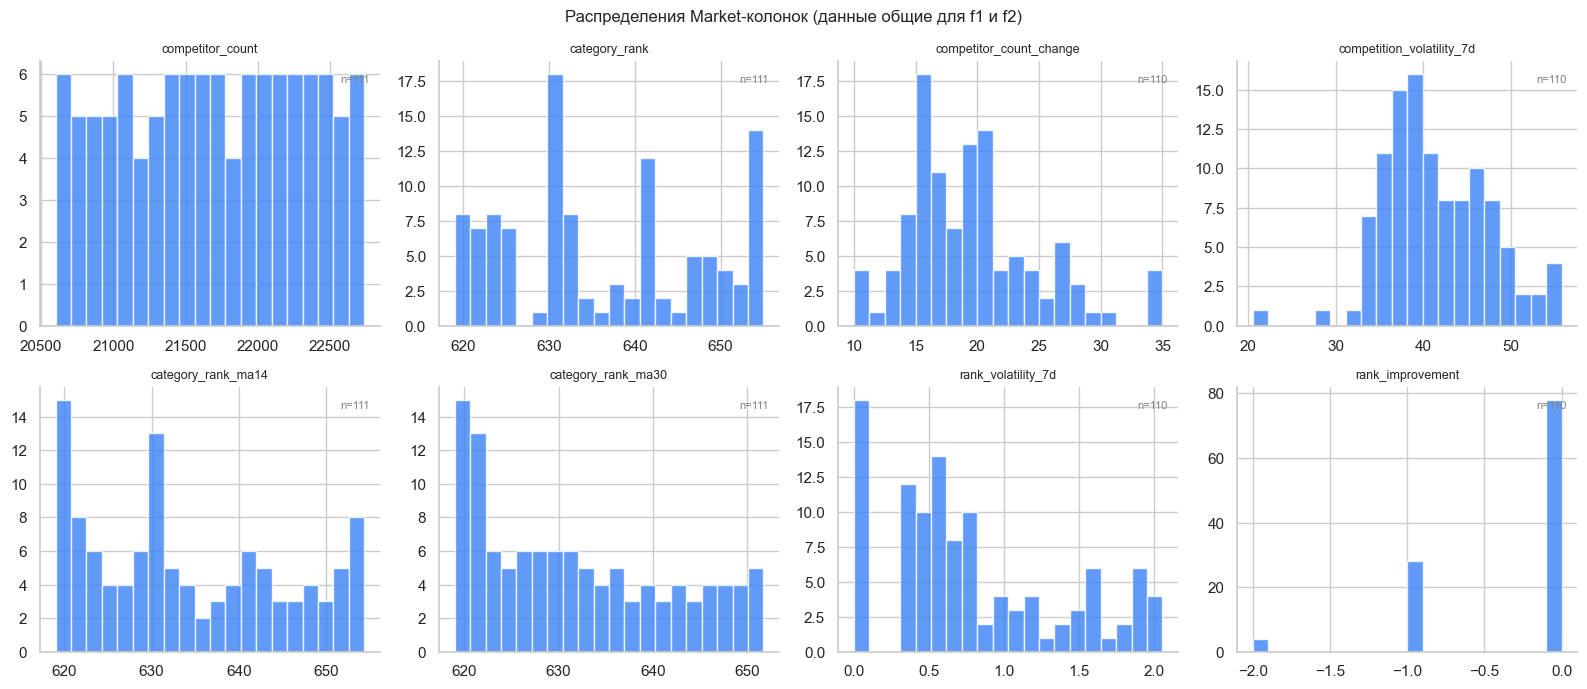

Сохранено: histograms_market.pdf


In [8]:
COLOR = APP_PALETTE["com.labpixies.flood"]  # единственный цвет — данные общие

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(MARKET_COLS):
    ax = axes.flat[i]
    valid = df_market_shared[col].dropna()
    ax.hist(valid, bins=20, color=COLOR, alpha=0.8, edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    n = valid.shape[0]
    ax.annotate(f"n={n}", xy=(0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=8, color="grey")

fig.suptitle("Распределения Market-колонок (данные общие для f1 и f2)", fontsize=12)
plt.tight_layout()
save_figure("histograms_market", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: histograms_market.pdf")


## 5. Динамика во времени

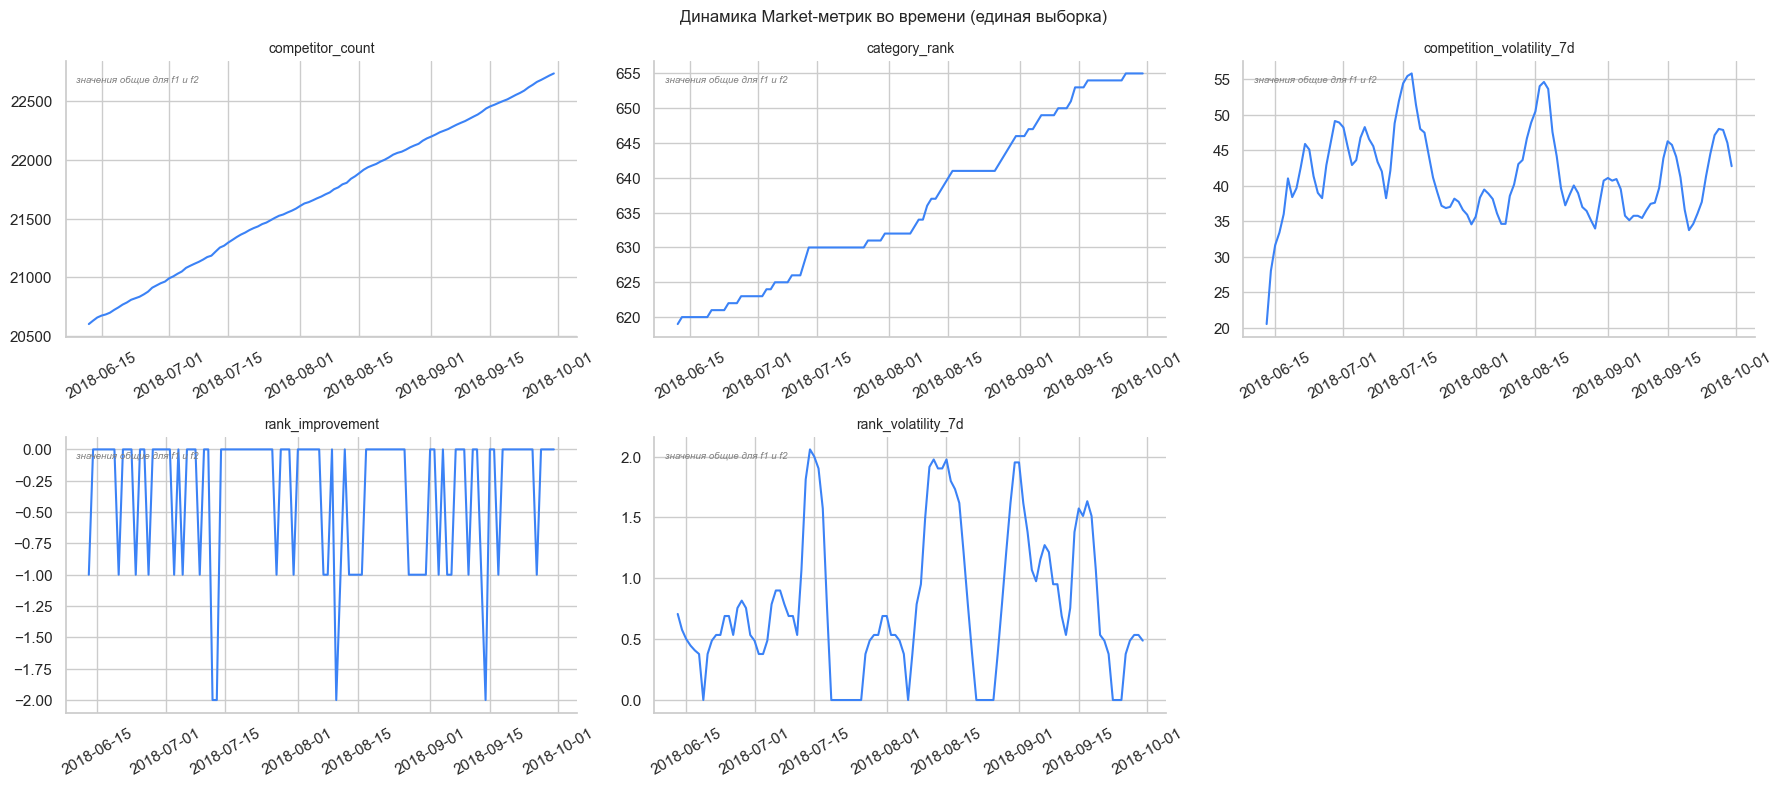

Сохранено: timeseries_market.pdf


In [9]:
COLOR = APP_PALETTE["com.labpixies.flood"]

TIMESERIES_COLS = [
    "competitor_count",
    "category_rank",
    "competition_volatility_7d",
    "rank_improvement",
    "rank_volatility_7d",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(TIMESERIES_COLS):
    ax = axes.flat[i]
    valid = df_market_shared[["date", col]].dropna()
    ax.plot(valid["date"], valid[col], color=COLOR, linewidth=1.5)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.annotate("значения общие для f1 и f2", xy=(0.02, 0.95),
                xycoords="axes fraction", ha="left", va="top",
                fontsize=7, color="grey", style="italic")

axes.flat[5].set_visible(False)
fig.suptitle("Динамика Market-метрик во времени (единая выборка)", fontsize=12)
plt.tight_layout()
save_figure("timeseries_market", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: timeseries_market.pdf")


## 6. Корреляции

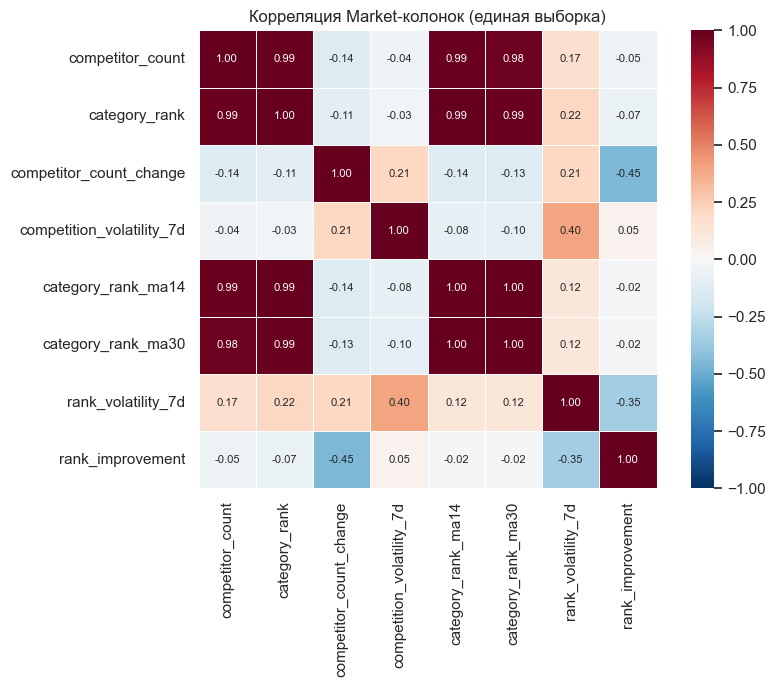

Сохранено: corr_market.pdf


In [10]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    corr = df_market_shared[MARKET_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=False, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Корреляция Market-колонок (единая выборка)", fontsize=12)
plt.tight_layout()
save_figure("corr_market", NOTEBOOK_SLUG)
plt.show()
print("Сохранено: corr_market.pdf")


In [11]:
print("Топ коррелированных пар |corr| > 0.7:")
pairs = top_correlated_pairs(corr, threshold=0.7, n=10)
print(pairs)


Топ коррелированных пар |corr| > 0.7:
category_rank_ma14  category_rank_ma30    0.997157
category_rank       category_rank_ma14    0.993838
                    category_rank_ma30    0.989394
competitor_count    category_rank         0.988175
                    category_rank_ma14    0.985901
                    category_rank_ma30    0.977917
dtype: float64


## 7. Особенности и выводы

### Выводы по Market-метрикам

**Рыночный контекст — категория Puzzle 2018:**
- Число конкурентов выросло с **20 601** до **22 737** за 111 дней (+**10,4%**, ~19 новых
  приложений в день) — рынок интенсивно расширялся.
- Категориальная позиция ухудшилась с **619** до **655** (−36 позиций), медиана = 632 — логично в
  условиях роста конкуренции: позиция «сносит» вниз даже без изменения абсолютных метрик продукта.
- `competition_volatility_7d` (std числа конкурентов за 7 дней): среднее 41.4 ± 6.1 — умеренный,
  но устойчивый рыночный шум.
- `rank_volatility_7d` (std позиции за 7 дней): медиана 0.69, max 2.06 — позиция практически не
  меняется внутри недели; рынок инерционен на коротком горизонте.
- `rank_improvement`: медиана = 0, 75th percentile = 0 — улучшения позиции за весь период не
  происходило ни разу; переменная почти константна.

**Сильные корреляции (|corr| > 0.9):**
- `category_rank_ma14` / `category_rank_ma30`: corr = **0.997** — почти идентичны, одну нужно
  исключить при VIF-анализе.
- `category_rank` / `category_rank_ma14`: corr = **0.994** — скользящее среднее дублирует ранг.
- `competitor_count` / `category_rank`: corr = **0.988** — растущий рынок и ухудшение позиции
  жёстко связаны (один единственный тренд «рынок растёт»).

VIF-фильтрация (`compute_vif` в `src/feature_engineering.py`, threshold=10) исключит большинство — а вероятно и все — переменные этой группы из-за высокой взаимной коллинеарности (corr > 0.977). Permutation importance уже на оставшихся кандидатах решит, останется ли что-то от market-кластера в финальном feature-set.

**Потенциально полезные для модели:**
- `competition_volatility_7d` — proxy «рыночного стресса»; при резком росте конкуренции может
  быть связан с падением retention через «канализацию» трафика.
- `rank_volatility_7d` — низкая волатильность позиции может быть положительным сигналом
  стабильности продукта.

**Главное ограничение:**
Market-метрики **идентичны** для com.labpixies.flood (успех) и com.google.flood2 (провал).
Они описывают общий рыночный фон и **не различают продукты**. Включение их в модель даёт
только «макро»-контекст; предсказательная сила по оси «успех vs провал» равна нулю.
При обучении сквозного pipeline это нейтрализуется VIF + permutation importance — market-признаки
войдут в модель только если дадут статистически значимый прирост точности.

## 8. Сохранение фигур

In [12]:
from notebooks._common import _PROJECT_ROOT
fig_dir = _PROJECT_ROOT / "figures" / NOTEBOOK_SLUG
print("Сохранённые фигуры:")
for p in sorted(fig_dir.glob("*.pdf")):
    print(f"  - {p.name}")


Сохранённые фигуры:
  - corr_market.pdf
  - histograms_market.pdf
  - nan_heatmap.pdf
  - timeseries_market.pdf
